<a href="https://colab.research.google.com/github/The1keyy/cs666student/blob/main/k_jeannot_CS666_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

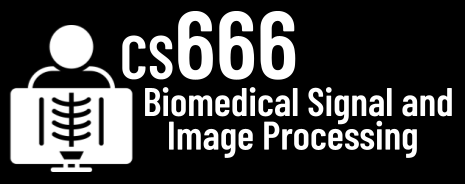
#Assignment 6

In [169]:
# NAME: Keyshawn Jeannot

In [170]:
# In this assignment, we will visualize and explore a CT scan!

In [171]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['f']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [172]:
# we are using pydicom, so lets install it!
!pip install pydicom

**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [173]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [174]:
# TODO: YOUR CODE

In [175]:
!wget https://cs666.org/data/ct.zip

--2026-05-07 03:34:37--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip.5’

ct.zip.5            100%[===================>]   5.58M  --.-KB/s    in 0.08s   

2026-05-07 03:34:37 (71.7 MB/s) - ‘ct.zip.5’ saved [5847706/5847706]



In [176]:
# Then use the following snippet to extract the data.

In [177]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [178]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [179]:
# TODO: There are 220 slices.

In [180]:
import glob
len(glob.glob("**/*.dcm", recursive=True))

220

In [181]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [182]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

In [183]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [184]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

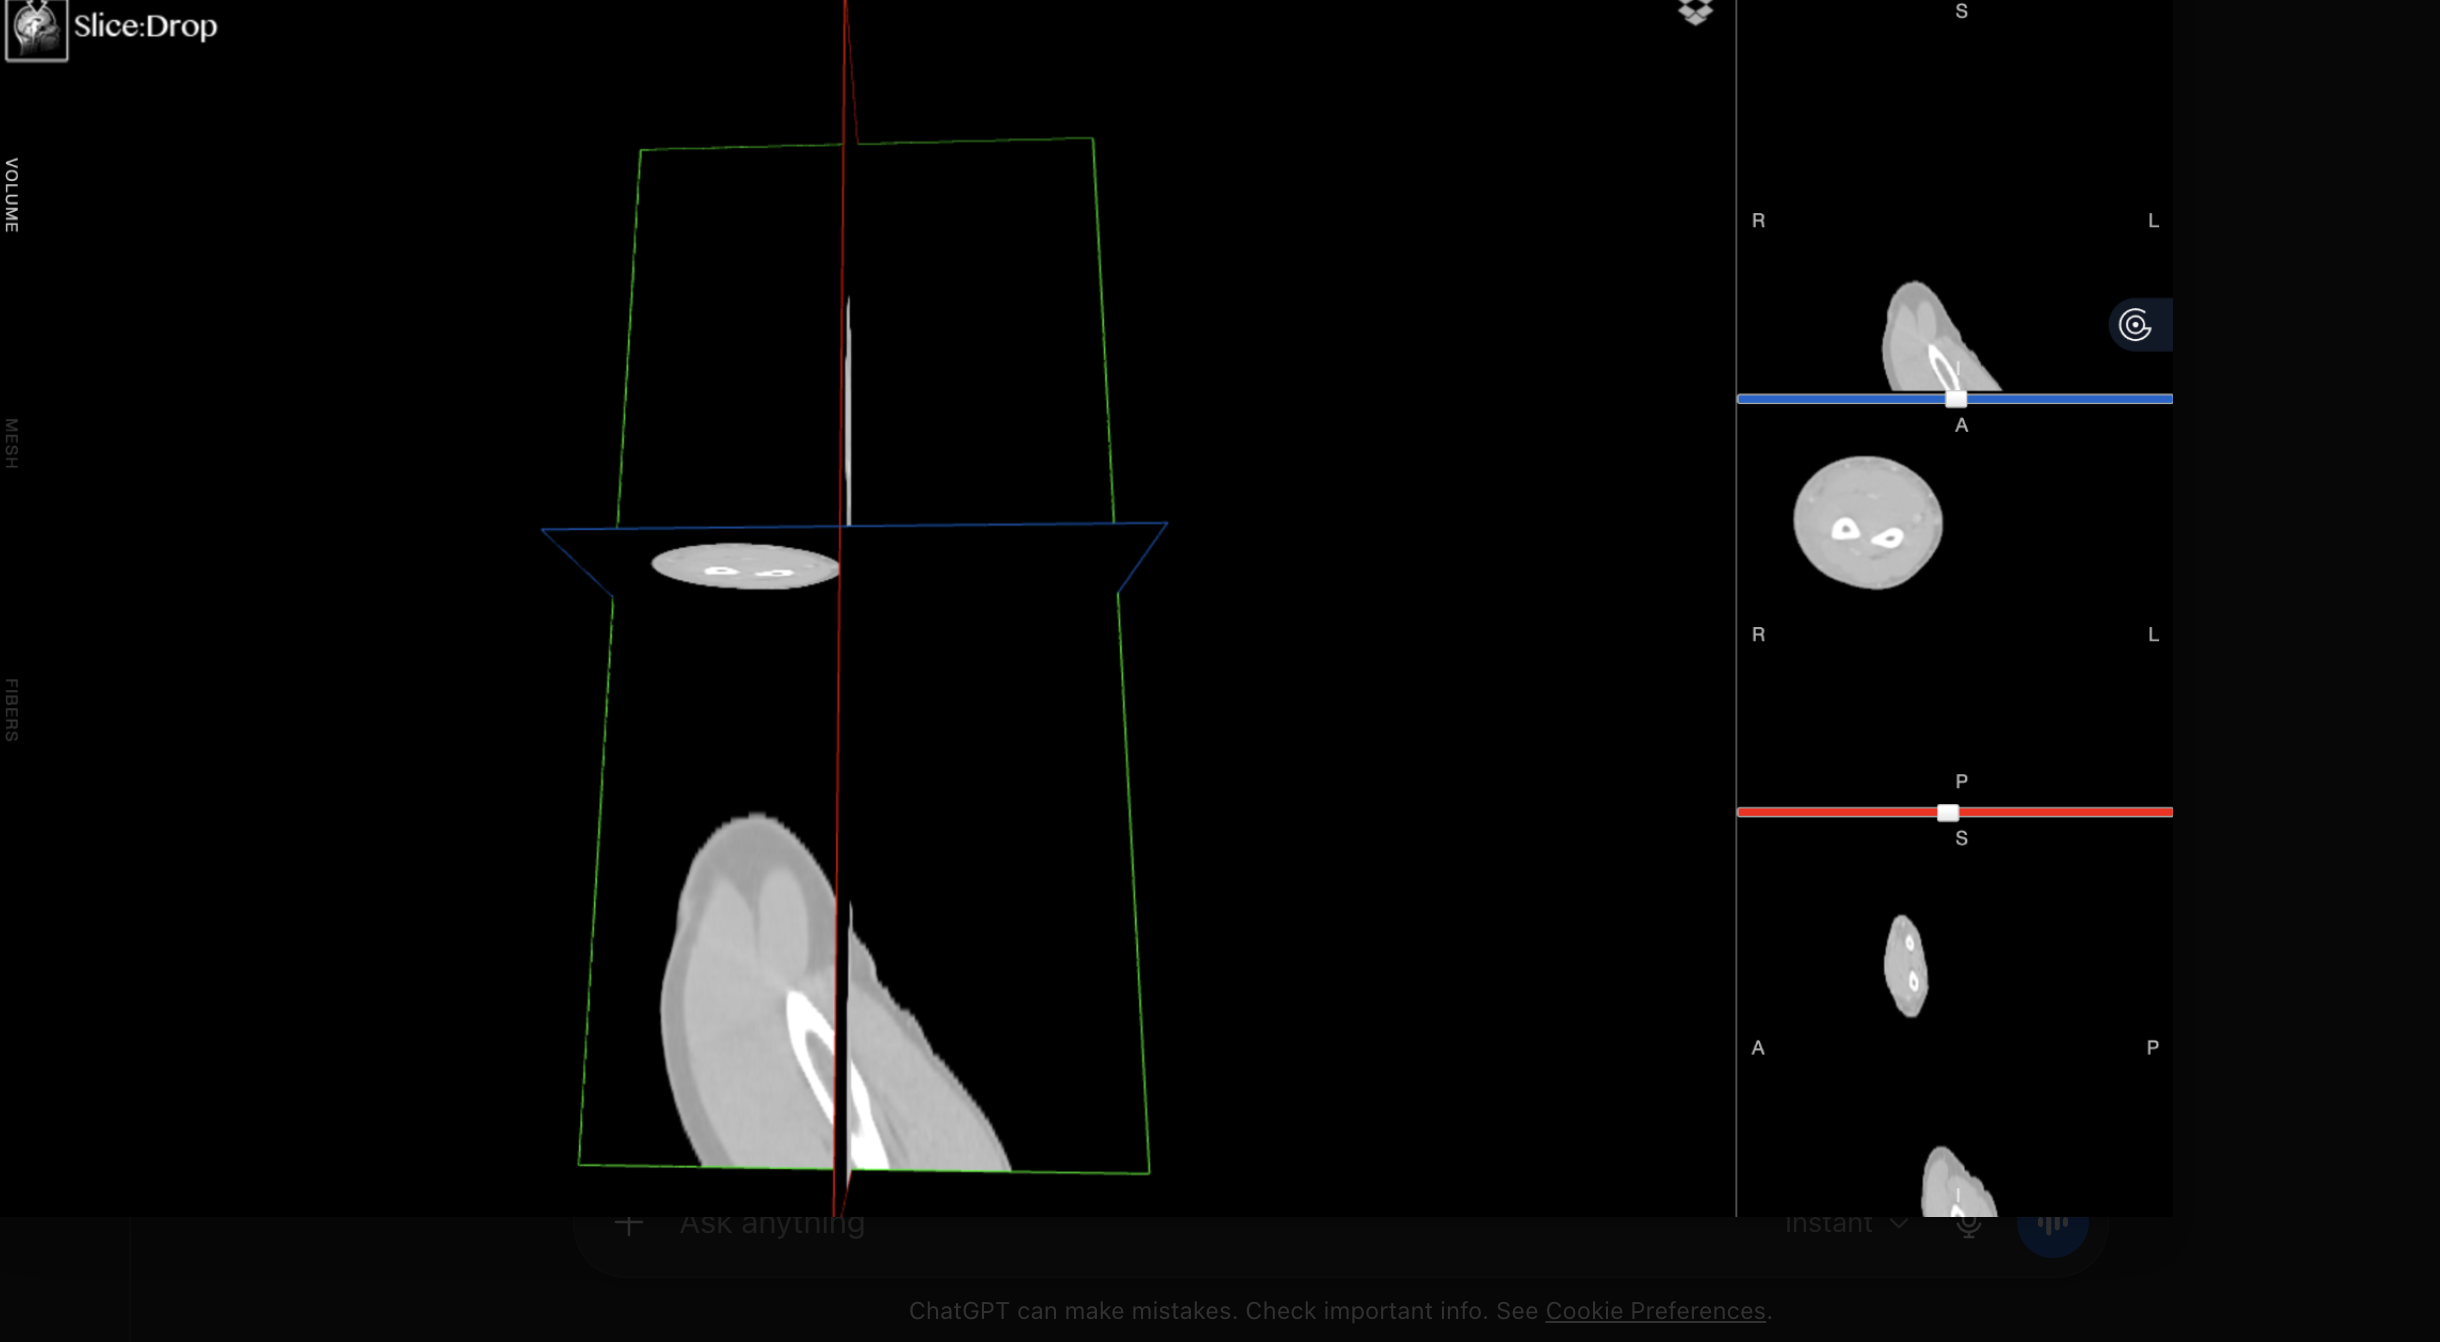

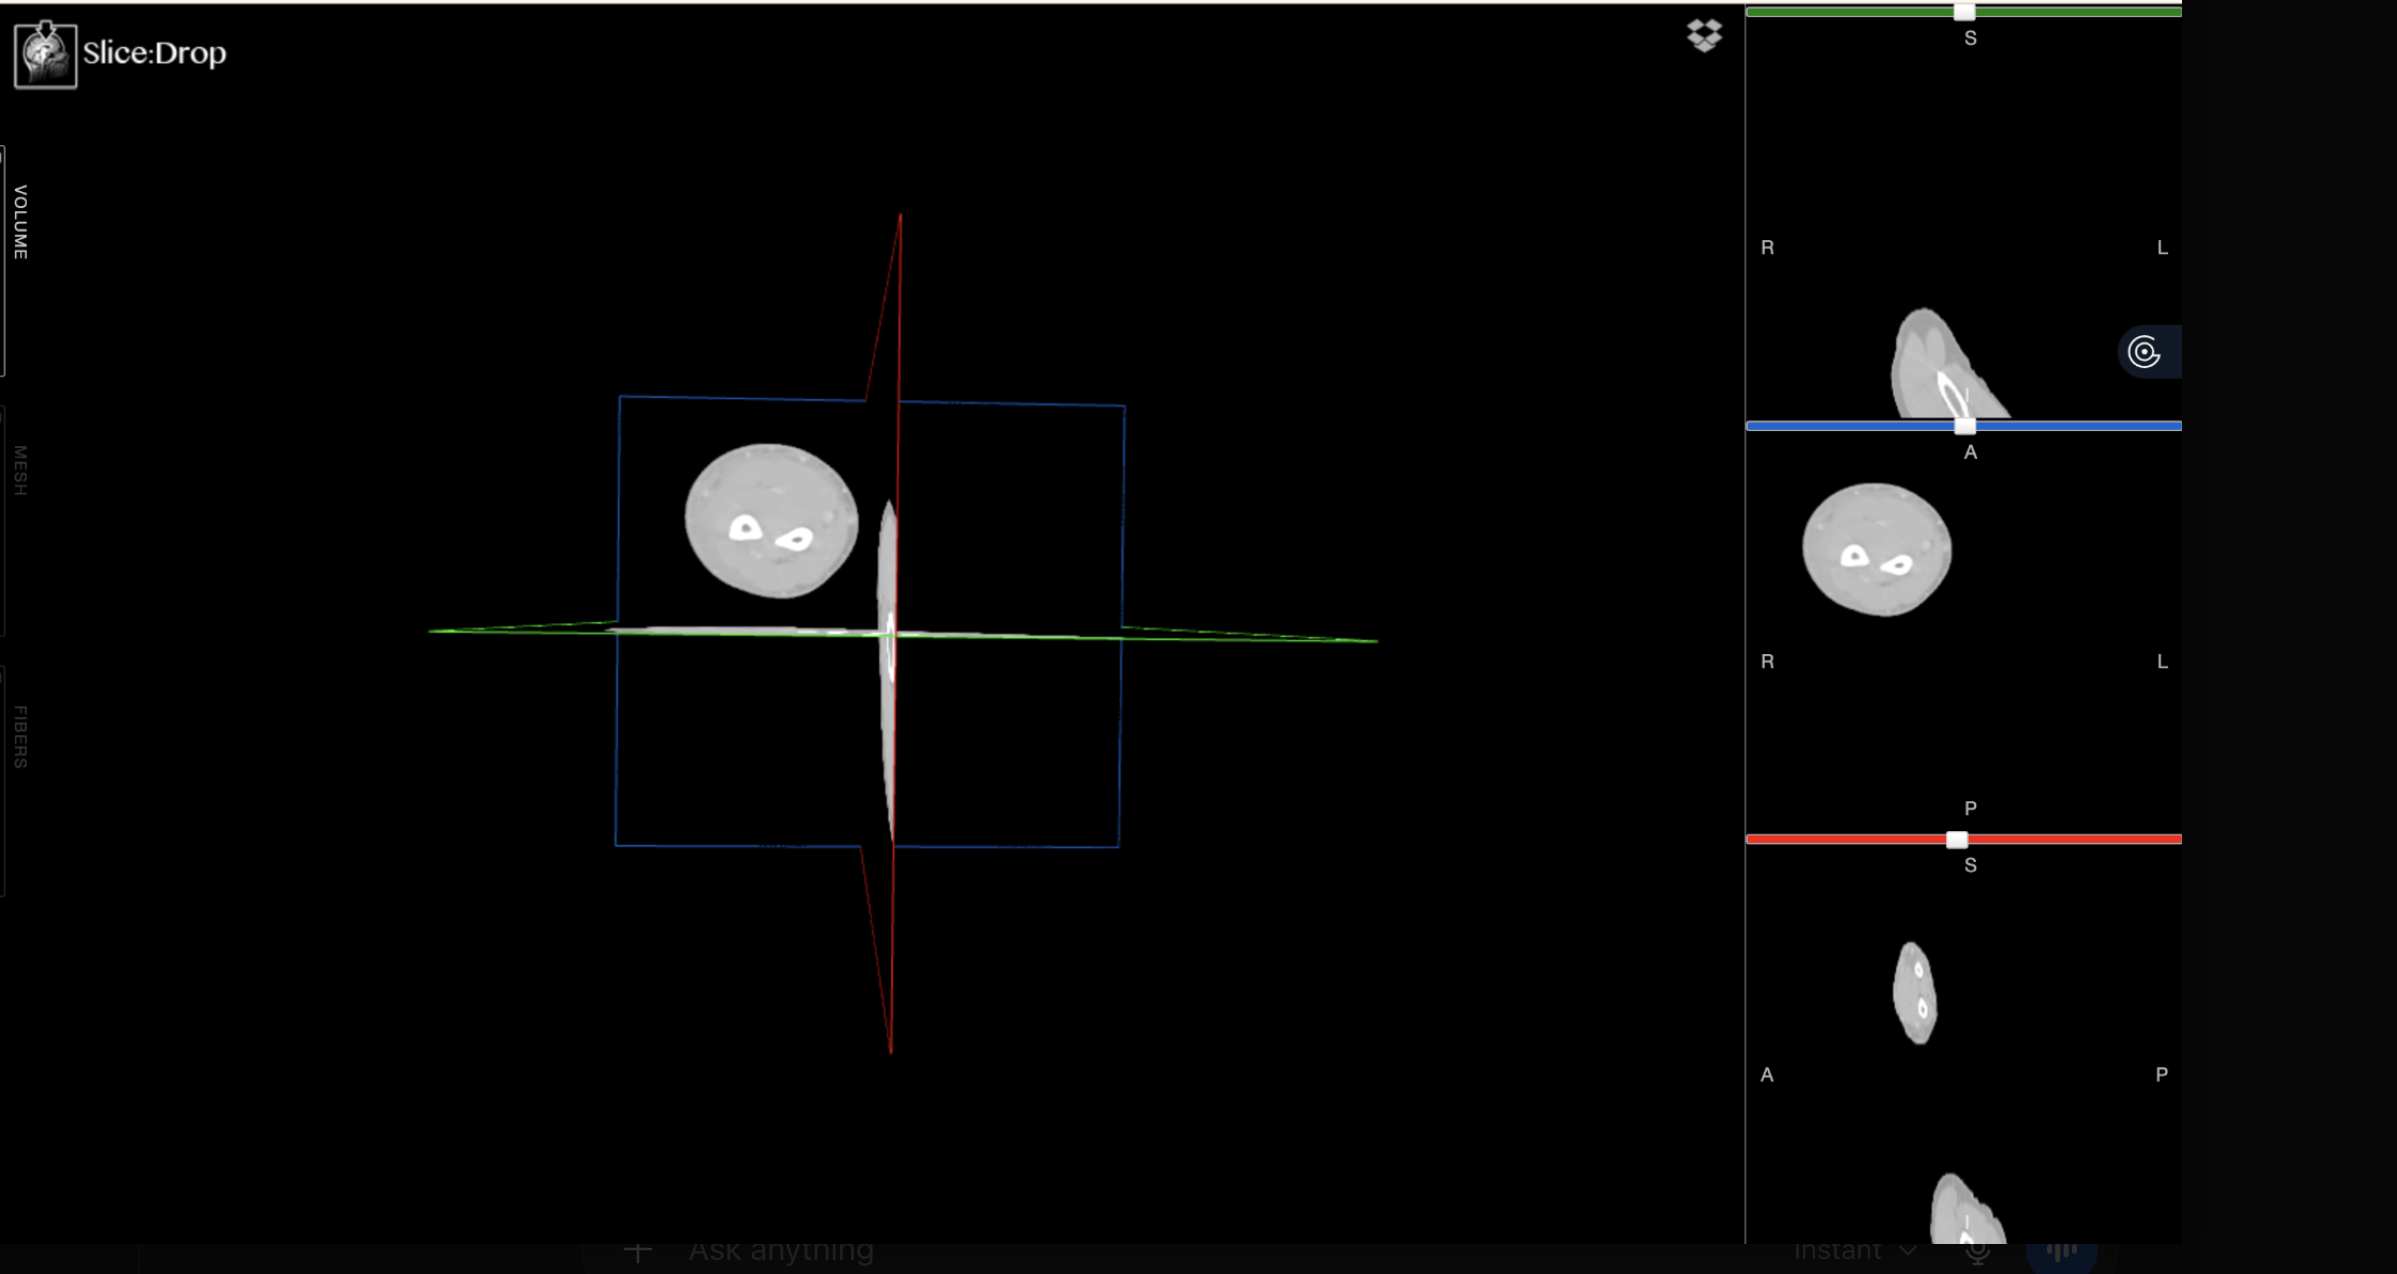

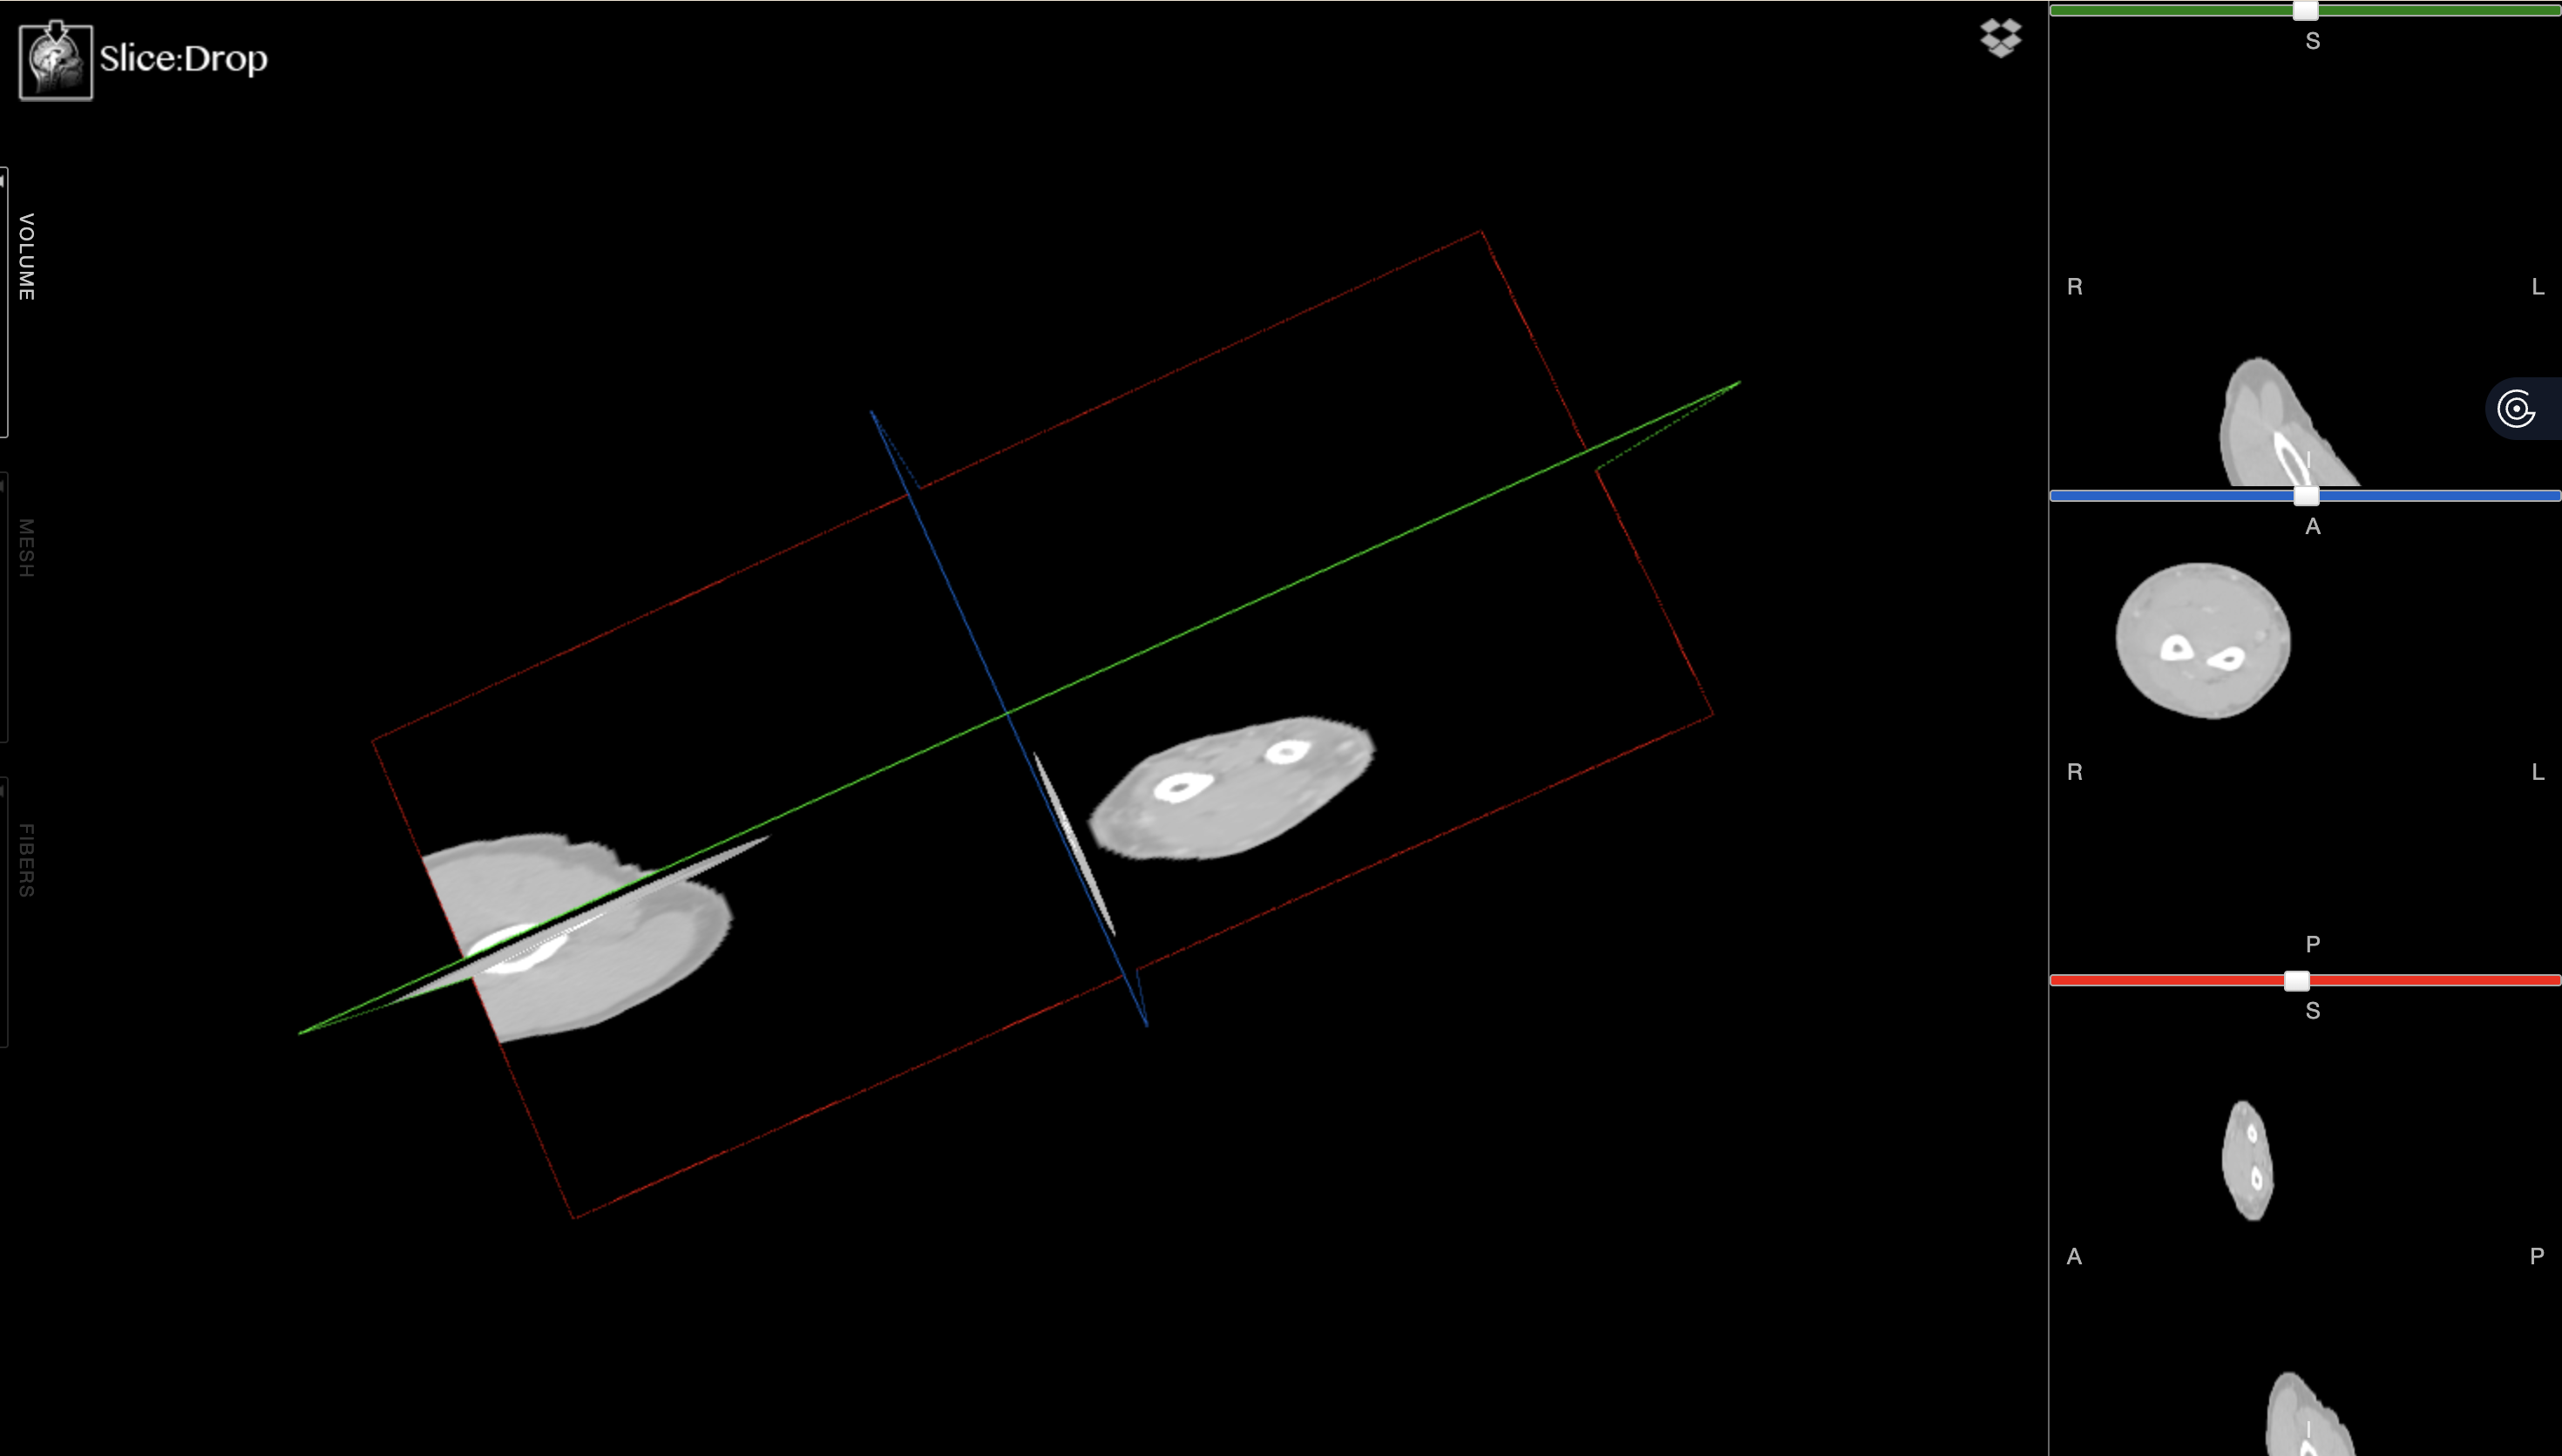

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [185]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [186]:
from pydicom import dcmread

In [187]:
# TODO:
import glob
import numpy as np

In [188]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

files = sorted(glob.glob("**/*.dcm", recursive=True))

imgs = []
for f in files:
    dcm = dcmread(f)
    imgs.append(dcm)

imgs.sort(key=lambda x: int(x.InstanceNumber))

volume = np.array([img.pixel_array for img in imgs])

print(volume.shape)

(220, 454, 512)


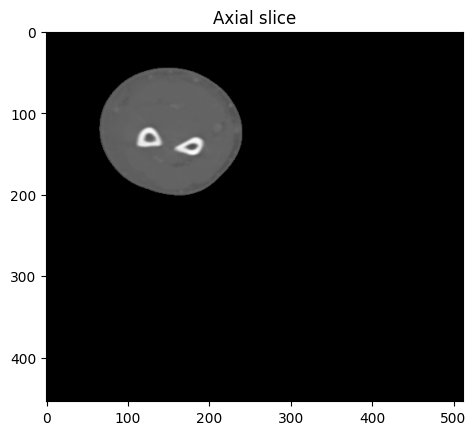

In [189]:
# TODO: YOUR CODE FOR AXIAL

imshow(volume[110], cmap='gray')
title("Axial slice")
show()

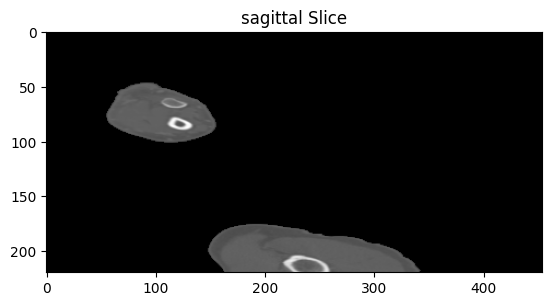

In [190]:
# TODO: YOUR CODE FOR SAGITTAL

imshow(volume[:, :, 256], cmap='gray')
title("sagittal Slice")
show()

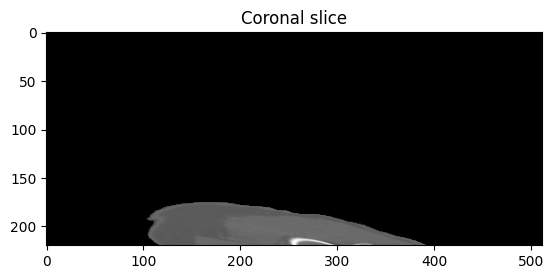

In [191]:
# TODO: YOUR CODE FOR CORONAL

imshow(volume[:, 256, :], cmap='gray')
title("Coronal slice")
show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [192]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [193]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

window center: 30
window width: 410
rescale intercept: -1024


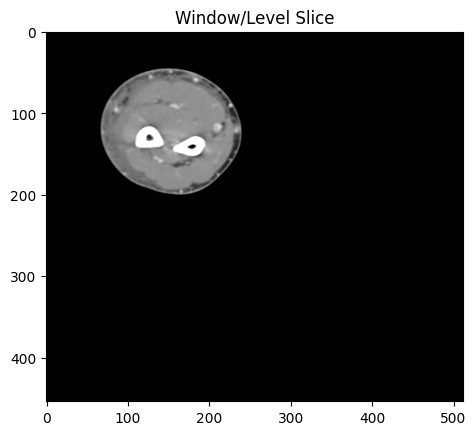

In [194]:
# TODO: YOUR CODE
dcm = imgs[110]

center = dcm[(0x0028, 0x1050)].value
width = dcm[(0x0028, 0x1051)].value
intercept = dcm[(0x0028, 0x1052)].value

print("window center:", center)
print("window width:", width)
print("rescale intercept:", intercept)

hu = volume.astype(np.int16) + int(intercept)

vmin = int(center) - int(width) / 2
vmax = int(center) + int(width) / 2

imshow(hu[110], cmap='gray', vmin=vmin, vmax=vmax)
title("Window/Level Slice")
show()

In [195]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

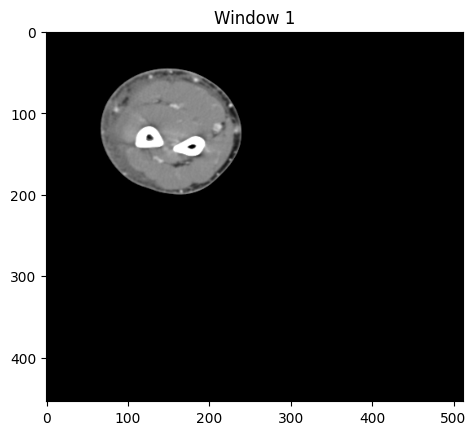

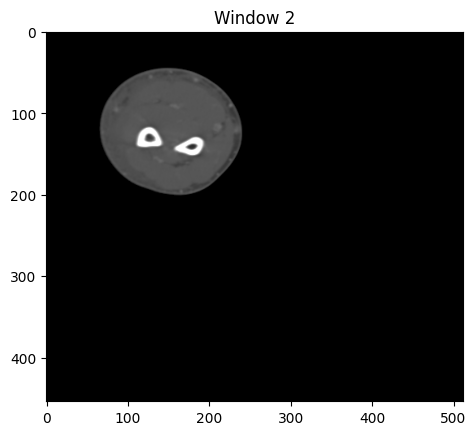

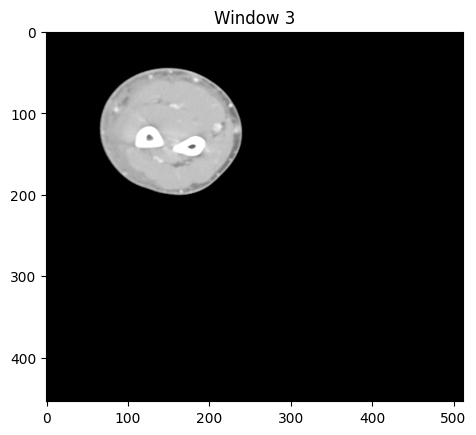

In [196]:
# TODO: YOUR CODE

level = 40
window = 400

imshow(hu[110], cmap='gray', vmin=level-window/2, vmax=level+window/2)
title("Window 1")
show()


level = 300
window = 1500

imshow(hu[110], cmap='gray', vmin=level-window/2, vmax=level+window/2)
title("Window 2")
show()


level = -100
window = 600

imshow(hu[110], cmap='gray', vmin=level-window/2, vmax=level+window/2)
title("Window 3")
show()

In [197]:
# Which values make sense and why?

In [198]:
# TODO: I think Window 1 and Window 2 make the most sense because they show the bones
# and soft tissue more clearly.

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [199]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

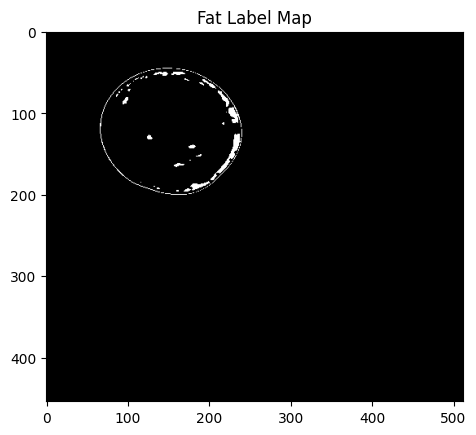

In [200]:
# TODO: YOUR CODE TO SEGMENT FAT

fat = (hu > -200) & (hu < -30)
imshow(fat[110], cmap='gray')
title("Fat Label Map")
show()

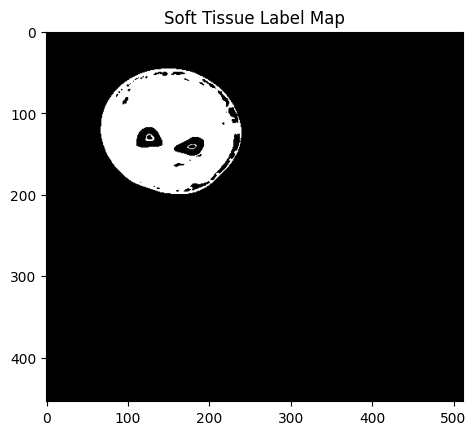

In [201]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE

soft_tissue = (hu >= -30) & (hu < 300)
imshow(soft_tissue[110], cmap='gray')
title("Soft Tissue Label Map")
show()


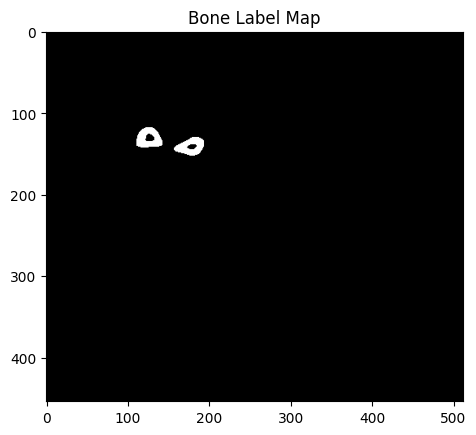

In [204]:
# TODO: YOUR CODE TO SEGMENT BONES

bone = hu >= 300
imshow(bone[110], cmap='gray')
title("Bone Label Map")
show()

In [ ]:
# Are the segmentations good?

In [ ]:
# TODO: YOUR ANSWER

#The fat and soft tissue segmentations are rough because their HU values are closer together,
# and some noise gets included.the bone segmentation looks the best because bone has very high HU values,
# so it is easier to separate from everything else.

In [ ]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""